# Chapter 4 (extra) — Volterra equations of the second kind

The main Chapter 4 notebook solves a *first-kind* Volterra equation
$\int_0^t K(t-z)f(z)\,dz = g(t)$ and obtains the **reversible** cyclic
voltammogram. When electron transfer is *not* fast the surface boundary
condition becomes Butler-Volmer rather than Nernstian, and the integral
equation picks up the unknown $f$ on *both* sides — a **second-kind**
Volterra equation,

$$f(t) = g(t) + \int_0^t K(t-z)\,f(z)\,dz .$$

Honeychurch (SERM §4.7) notes that, after applying Huber's piecewise
approximation, the second-kind discrete equation differs from the
first-kind one *only in the leading right-hand-side term*. The kernel
weights are the same $k^{3/2}-(k-1)^{3/2}$ Huber weights. This notebook
re-implements the second-kind recurrence for the two classic cases of
Nicholson & Olmstead (1972): a **totally irreversible** wave and a
**quasi-reversible** wave, and validates each against an independent
closed-form peak coefficient.


In [1]:
import os, sys

# Walk up from the notebook's working directory to the repo root (the directory
# that contains the ``serm`` package); works whether this notebook is run from
# notebooks/ or notebooks/extras/.
_d = os.getcwd()
while not os.path.isdir(os.path.join(_d, "serm")) and os.path.dirname(_d) != _d:
    _d = os.path.dirname(_d)
sys.path.insert(0, _d)

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op
# under headless (Agg) execution.
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

import serm
from serm import echem
from serm.tridiagonal import tridiag_solve

np.set_printoptions(precision=6, suppress=True)


## 1. The Huber weights

For the planar diffusion kernel $K(y)=1/\sqrt{\pi y}$, integrating the
piecewise-constant $f$ over each step of width $d$ produces the Huber
weight for a lag of $k$ steps,

$$w_k = k^{3/2}-(k-1)^{3/2},$$

with the leading (self) coefficient $h_1 = \tfrac{4}{3}\,d^{3/2}$
(the same $\tfrac43 d^{3/2}$ that appears in the first-kind solver of the
main notebook). Below, the convolution sum
$S^{(1)}_m=\sum_{i<m} w_{m-i}\,a_i$ is what couples step $m$ to its
history; we evaluate it with a vectorised dot product.


In [2]:
def huber_lag_weights(m: int) -> np.ndarray:
    """Huber lag weights ``w_k = k**1.5 - (k-1)**1.5`` for k = m-1 .. 1.

    Returns the weights already ordered to multiply the history
    ``a[0], a[1], ..., a[m-2]`` (i.e. lag decreasing from ``m-1`` to 1).
    """
    ii = np.arange(1, m)                 # i = 1 .. m-1
    lag = m - ii                         # k = m-i
    return lag ** 1.5 - (lag - 1) ** 1.5


## 2. Totally irreversible cyclic voltammetry

For a totally irreversible reduction $O + n e^- \to R$ only the forward
Butler-Volmer term survives. Following Nicholson & Olmstead via SERM
§4.7, working on the dimensionless potential axis
$\alpha\,\tfrac{nF}{RT}(E-E_0)$ with step $\Delta e$ and a rate group

$$g_m = \frac{\sqrt{\pi\,\alpha\,(nF/RT)\,v\,D}}{k_i}\,
e^{-m\alpha\Delta e},\qquad k_i = k_s\,e^{-\alpha p_0},$$

the second-kind recurrence for the interval slopes $a_m$ is

$$a_m = \frac{1}{g_m\alpha\Delta e + h_1}
\Bigl(1 - h_1\!\sum_{i<m} w_{m-i}\,a_i
- g_m\alpha\Delta e\!\sum_{i<m} a_i\Bigr),$$

and the dimensionless current function is the running sum
$\chi_m = \sqrt{\pi}\,\alpha\Delta e\sum_{i\le m} a_i$, with the
Huber self-weight $h_1 = \tfrac43 (\alpha\Delta e)^{3/2}$ (the kernel
step width on this axis is $\alpha\Delta e$). The forward peak of $\chi$
is the **Nicholson-Shain totally-irreversible coefficient $0.4958$** —
our validation target.


In [3]:
def irreversible_cv(
    n: int = 2000, de: float = 0.02, ks: float = 1e-5,
    alpha: float = 0.5, D: float = 1e-5, v: float = 1.0, p0: float = 10.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Totally irreversible CV via the second-kind Volterra equation.

    Parameters
    ----------
    n : int
        Number of potential steps.
    de : float
        Dimensionless potential step on the ``alpha*(nF/RT)(E-E0)`` axis.
    ks : float
        Standard heterogeneous rate constant (cm/s).
    alpha : float
        Transfer coefficient.
    D : float
        Diffusion coefficient (cm^2/s).
    v : float
        Sweep rate (V/s).
    p0 : float
        Dimensionless start potential (units anodic of E0).

    Returns
    -------
    (potential, chi) : tuple of ndarray, shape (n,)
        Dimensionless potential ``alpha*(nF/RT)(E-E0)`` and current
        function ``chi``.
    """
    F, R, T = echem.F, echem.R, 298.15
    ki = ks * np.exp(-alpha * p0)
    # Huber self-weight on the irreversible axis: the step width is the
    # dimensionless increment alpha*de, hence (alpha*de)**1.5.
    h1 = (4.0 / 3.0) * (alpha * de) ** 1.5
    pref = np.sqrt(np.pi * alpha * (F / (R * T)) * v * D) / ki
    a = np.zeros(n)
    for m in range(1, n + 1):
        g = pref * np.exp(-m * alpha * de)
        if m > 1:
            w = huber_lag_weights(m)
            s1 = np.dot(a[:m - 1], w)        # history convolution
            s2 = a[:m - 1].sum()
        else:
            s1 = s2 = 0.0
        gade = g * alpha * de
        a[m - 1] = (1.0 - h1 * s1 - gade * s2) / (gade + h1)
    chi = np.sqrt(np.pi) * alpha * de * np.cumsum(a)
    potential = p0 - alpha * de * np.arange(1, n + 1)
    return potential, chi


irreversible peak chi = 0.49670  (Nicholson-Shain coefficient 0.4958)


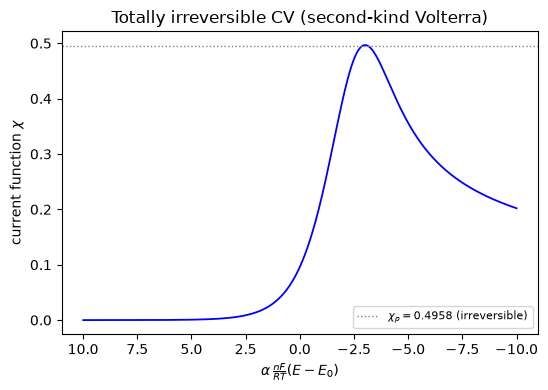

In [4]:
pot_irr, chi_irr = irreversible_cv()
ip_irr = chi_irr.max()
print(f"irreversible peak chi = {ip_irr:.5f}  "
      f"(Nicholson-Shain coefficient 0.4958)")

fig, ax = plt.subplots(figsize=(5.6, 4))
ax.plot(pot_irr, chi_irr, "b-", lw=1.3)
ax.axhline(0.4958, color="0.5", ls=":", lw=1.0,
           label=r"$\chi_p = 0.4958$ (irreversible)")
ax.invert_xaxis()
ax.set_xlabel(r"$\alpha\,\frac{nF}{RT}(E - E_0)$")
ax.set_ylabel(r"current function $\chi$")
ax.set_title("Totally irreversible CV (second-kind Volterra)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 3. Quasi-reversible cyclic voltammetry

For a quasi-reversible couple both Butler-Volmer terms survive and the
wave shape depends on the dimensionless kinetic parameter

$$\psi = \frac{k_s}{\sqrt{\pi\,(nF/RT)\,v\,D}} .$$

Working on the reversible potential axis $\tfrac{nF}{RT}(E-E_0)$ with
step $\Delta e$, $g_m = e^{-m\Delta e}$, $c_1 = e^{\alpha p_0}/\psi$
and $c_2 = e^{p_0}$, the second-kind recurrence (SERM §4.7, after
Nicholson & Olmstead 1972) is

$$a_m = \frac{1 - (1+c_2 g_m)\,h_1\sum_{i<m} w_{m-i}a_i
- c_1 g_m^{\alpha}\Delta e\sum_{i<m} a_i}
{c_1 g_m^{\alpha}\Delta e + h_1 + c_2 g_m h_1},
\qquad h_1=\tfrac43\Delta e^{3/2}.$$

As $k_s\to\infty$, $\psi\to\infty$ so $c_1\to0$ and the equation
collapses to the *first-kind* reversible solver: the peak must approach
the **Randles-Sevcik constant $0.4463$**. That is the
reduction-to-validated-limit check for this solver.


In [5]:
def quasireversible_cv(
    ks: float, n: int = 1500, de: float = 0.02,
    alpha: float = 0.5, D: float = 1e-5, v: float = 1.0, p0: float = 10.0,
) -> tuple[np.ndarray, np.ndarray]:
    """Quasi-reversible CV via the second-kind Volterra equation.

    Same parameters as :func:`irreversible_cv` except the potential axis
    is the reversible ``(nF/RT)(E-E0)`` (no ``alpha`` factor). As
    ``ks -> inf`` the result reduces to the Nernstian reversible CV.

    Returns
    -------
    (potential, chi) : tuple of ndarray, shape (n,)
    """
    F, R, T = echem.F, echem.R, 298.15
    psi = ks / np.sqrt(np.pi * (F / (R * T)) * v * D)
    h1 = (4.0 / 3.0) * de ** 1.5
    c1 = np.exp(alpha * p0) / psi
    c2 = np.exp(p0)
    a = np.zeros(n)
    for m in range(1, n + 1):
        g = np.exp(-m * de)
        if m > 1:
            w = huber_lag_weights(m)
            s1 = np.dot(a[:m - 1], w)
            s2 = a[:m - 1].sum()
        else:
            s1 = s2 = 0.0
        c1g = c1 * g ** alpha * de
        denom = c1g + h1 + c2 * g * h1
        a[m - 1] = (1.0 - (1.0 + c2 * g) * h1 * s1 - c1g * s2) / denom
    chi = np.sqrt(np.pi) * de * np.cumsum(a)
    potential = p0 - de * np.arange(1, n + 1)
    return potential, chi


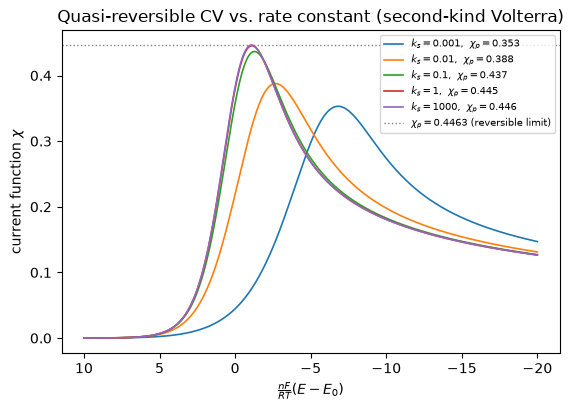

ks -> infinity peak: 0.44649 (Randles-Sevcik 0.4463)


In [6]:
ks_values = [1e-3, 1e-2, 1e-1, 1.0, 1e3]
fig, ax = plt.subplots(figsize=(5.8, 4.2))
peaks = {}
for ks in ks_values:
    pot_q, chi_q = quasireversible_cv(ks)
    peaks[ks] = chi_q.max()
    ax.plot(pot_q, chi_q, lw=1.2,
            label=fr"$k_s={ks:g}$,  $\chi_p={chi_q.max():.3f}$")
ax.axhline(0.4463, color="0.5", ls=":", lw=1.0,
           label=r"$\chi_p=0.4463$ (reversible limit)")
ax.invert_xaxis()
ax.set_xlabel(r"$\frac{nF}{RT}(E - E_0)$")
ax.set_ylabel(r"current function $\chi$")
ax.set_title("Quasi-reversible CV vs. rate constant (second-kind Volterra)")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

print("ks -> infinity peak:", f"{peaks[1e3]:.5f}",
      "(Randles-Sevcik 0.4463)")


## 4. Validation

Both checks are **tier 1 (independent closed-form coefficient)**, with
the quasi-reversible one doubling as a **tier 2 reduction-to-validated
limit** ($k_s\to\infty$ recovers the Nernstian reversible CV already
validated in the main Chapter 4 notebook).

1. The totally-irreversible current function peaks at the
   **Nicholson-Shain coefficient $0.4958$** (Bard & Faulkner,
   *Electrochemical Methods*, 2nd ed., irreversible LSV).
2. As $k_s\to\infty$ the quasi-reversible solver reduces to the
   reversible wave, peaking at the **Randles-Sevcik constant $0.4463$**,
   cross-checked dimensionally against
   `serm.echem.randles_sevcik_peak_current`. For decreasing $k_s$ the
   peak must fall monotonically below the reversible value (the
   signature of sluggish kinetics).


In [7]:
# --- Validation 1: irreversible peak == 0.4958 (tier 1, closed form) ---
target_irr = 0.4958
rel_irr = abs(ip_irr - target_irr) / target_irr
print(f"irreversible peak = {ip_irr:.5f}, target = {target_irr}, "
      f"rel. err = {rel_irr:.2e}")
assert rel_irr < 5e-3, "irreversible peak does not match 0.4958"
print("PASS: second-kind Volterra reproduces the irreversible 0.4958 peak.")


irreversible peak = 0.49670, target = 0.4958, rel. err = 1.81e-03
PASS: second-kind Volterra reproduces the irreversible 0.4958 peak.


In [8]:
# --- Validation 2: ks->inf reduces to reversible Randles-Sevcik (tier 1/2) ---
pot_rev, chi_rev = quasireversible_cv(ks=1e4)
ip_rev = chi_rev.max()
target_rev = 0.4463
rel_rev = abs(ip_rev - target_rev) / target_rev
print(f"ks->inf peak = {ip_rev:.5f}, Randles-Sevcik = {target_rev}, "
      f"rel. err = {rel_rev:.2e}")
assert rel_rev < 5e-3, "ks->inf peak does not match Randles-Sevcik 0.4463"

# Dimensional cross-check against serm.echem (independent closed form).
F, R = echem.F, echem.R
n_e, A, D, c_bulk, v, Tk = 1, 1.0, 1e-5, 1e-6, 1.0, 298.15
sigma = n_e * F * v / (R * Tk)
ip_dim = n_e * F * A * c_bulk * np.sqrt(D * sigma) * ip_rev
ip_closed = echem.randles_sevcik_peak_current(n_e, A, D, c_bulk, v,
                                              temperature=Tk)
rel_dim = abs(ip_dim - ip_closed) / ip_closed
print(f"dimensional i_p (Volterra) = {ip_dim:.6e} A,  "
      f"closed form = {ip_closed:.6e} A,  rel. err = {rel_dim:.2e}")
assert rel_dim < 5e-3, "dimensional reversible peak disagrees with serm.echem"

# Monotonic suppression of the peak as kinetics slow down.
ordered = [peaks[k] for k in sorted(peaks)]   # increasing ks
assert all(ordered[i] <= ordered[i + 1] + 1e-3 for i in range(len(ordered) - 1)), \
    "peak should grow monotonically toward the reversible limit as ks increases"
assert ordered[0] < target_rev, "slowest-kinetics peak should sit below reversible"
print("PASS: quasi-reversible solver reduces to Randles-Sevcik 0.4463 as "
      "ks->inf; peak grows monotonically with ks.")


ks->inf peak = 0.44649, Randles-Sevcik = 0.4463, rel. err = 4.36e-04
dimensional i_p (Volterra) = 8.499114e-04 A,  closed form = 8.495410e-04 A,  rel. err = 4.36e-04
PASS: quasi-reversible solver reduces to Randles-Sevcik 0.4463 as ks->inf; peak grows monotonically with ks.


## 5. Summary

The second-kind Volterra equation extends the integral-equation method to
non-Nernstian electron transfer. A single change to the leading
right-hand-side term of the first-kind recurrence yields:

- a **totally irreversible** CV whose current function peaks at the
  Nicholson-Shain coefficient $0.4958$; and
- a **quasi-reversible** family parameterised by $\psi$, which recovers
  the reversible Randles-Sevcik peak $0.4463$ as $k_s\to\infty$ and
  shows the expected peak suppression and cathodic shift as kinetics slow.

Both were validated against independent closed-form peak coefficients,
with the quasi-reversible $k_s\to\infty$ limit also serving as a
reduction to the already-validated reversible solver.


<!-- nav-footer -->

---

[← Chapter 4 — Other Numerical Methods](../04_other_numerical_methods.ipynb)

[Contents (README)](../../README.md)